In [22]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("Twitter_Data.csv")   #load the dataset

#total number of samples
print(f"Total Samples: {df.shape[0]}")
print(f"Columns: {df.columns.tolist()}")

df.head()   #display first few rows

Total Samples: 162980
Columns: ['clean_text', 'category']


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [24]:
# 2. Check class distribution
distribution = df['category'].value_counts()
percentage = df['category'].value_counts(normalize=True) * 100

print("--- Class Distribution ---")
print(distribution)
print("\n--- Percentage Distribution ---")
print(percentage)

--- Class Distribution ---
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64

--- Percentage Distribution ---
category
 1.0    44.332497
 0.0    33.878618
-1.0    21.788885
Name: proportion, dtype: float64


Total valid samples: 162969

--- Class Distribution ---
Negative (-1.0): 35509 samples
Neutral (0.0): 55211 samples
Positive (1.0): 72249 samples


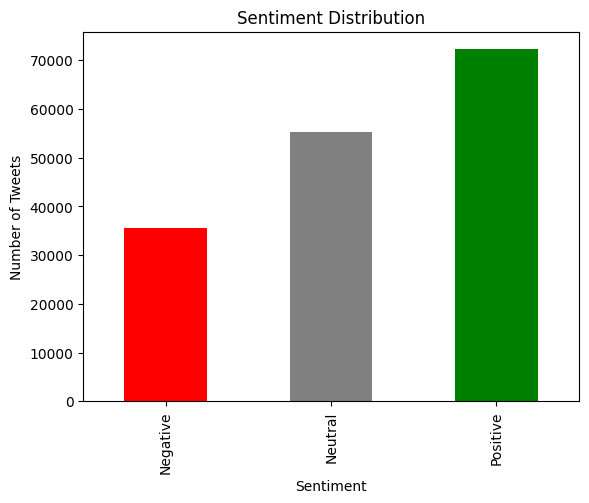

In [ ]:
import matplotlib.pyplot as plt

# Load your specific file
df = pd.read_csv('Twitter_Data.csv')

# Drop any null rows
df = df.dropna()

# 1. Basic Stats
total_samples = len(df)
print(f"Total valid samples: {total_samples}")

# 2. Class Distribution
# -1 = Negative, 0 = Neutral, 1 = Positive
dist = df['category'].value_counts().sort_index()

# Create a mapping for better readability in output
mapping = {-1: "Negative", 0: "Neutral", 1: "Positive"}

print("\n--- Class Distribution ---")
for val, count in dist.items():
    print(f"{mapping[val]} ({val}): {count} samples")

# Visualize the distribution
dist.rename(index=mapping).plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.savefig('sentiment_distribution.png')

In [26]:
import re
import numpy as np
from collections import Counter

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\Apurva
[nltk_data]     gosavi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Apurva
[nltk_data]     gosavi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Apurva
[nltk_data]     gosavi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Apurva
[nltk_data]     gosavi\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Apurva
[nltk_data]     gosavi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [27]:
# --- 2. NLP PREPROCESSING ---
def preprocess_text(text):
    # Lowercasing
    text = str(text).lower()
    # Remove URLs and Handles
    text = re.sub(r'http\S+|www\S+|https\S+|\@\w+', '', text, flags=re.MULTILINE)
    # Remove Special Characters and Punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove Numbers
    text = re.sub(r'\d+', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Stopwords Removal
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    return " ".join(tokens)

# Apply Preprocessing
print("Preprocessing data... please wait.")
df['clean_text'] = df['clean_text'].apply(preprocess_text)

Preprocessing data... please wait.


In [28]:
# --- 3. FEATURE ENGINEERING (Vectorization) ---
X = df['clean_text']
y = df['category']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bag of Words (BoW)
bow_vec = CountVectorizer(max_features=5000)
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow = bow_vec.transform(X_test)

# TF-IDF
tfidf_vec = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

In [29]:
# --- 4. MODEL BUILDING & EVALUATION ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier()
}

results = []

def evaluate_model(name, model, X_tr, X_te, vectorizer_type):
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1  = f1_score(y_test, y_pred, average='weighted')
    
    return {
        "Model": name,
        "Vectorization": vectorizer_type,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1-Score": f1
    }

# Running experiments for both BoW and TF-IDF
for name, model in models.items():
    # Evaluate with BoW
    results.append(evaluate_model(name, model, X_train_bow, X_test_bow, "BoW"))
    # Evaluate with TF-IDF
    results.append(evaluate_model(name, model, X_train_tfidf, X_test_tfidf, "TF-IDF"))

In [31]:
# --- 5. COMPARISON & INSIGHTS ---
results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison ---")
print(results_df.sort_values(by='F1-Score', ascending=False))

# Summary of Findings
best_row = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"\nBest Performing Pipeline: {best_row['Model']} using {best_row['Vectorization']}")


--- Model Performance Comparison ---
                 Model Vectorization  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression           BoW  0.886666   0.887013  0.886666  0.885935
1  Logistic Regression        TF-IDF  0.879794   0.880990  0.879794  0.878559
4        Decision Tree           BoW  0.831902   0.831400  0.831902  0.831590
5        Decision Tree        TF-IDF  0.801313   0.800058  0.801313  0.800568
2          Naive Bayes           BoW  0.774376   0.776557  0.774376  0.774413
3          Naive Bayes        TF-IDF  0.716696   0.754868  0.716696  0.704141

Best Performing Pipeline: Logistic Regression using BoW


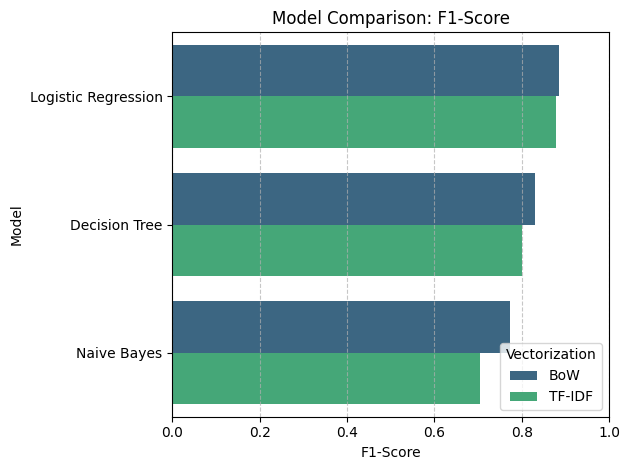

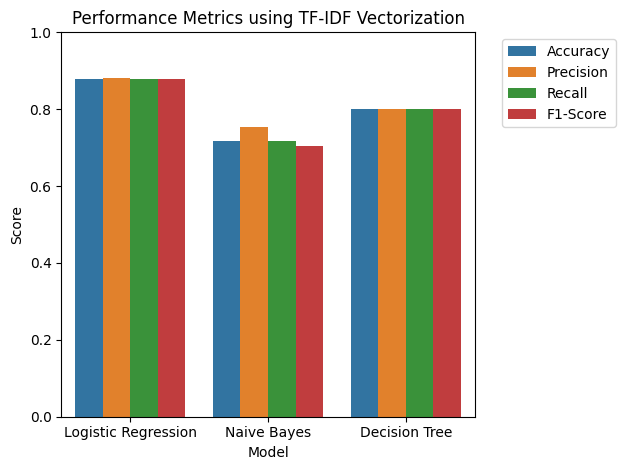

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for plotting
plot_df = results_df.melt(id_vars=['Model', 'Vectorization'], 
                          value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'], 
                          var_name='Metric', value_name='Score')

# 2. Visualize F1-Score Comparison 
f1_data = results_df.sort_values(by='F1-Score', ascending=False)
sns.barplot(x='F1-Score', y='Model', hue='Vectorization', data=f1_data, palette='viridis')
plt.title('Model Comparison: F1-Score')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.close()

# 3. Visualize All Metrics for a specific Vectorization (e.g., TF-IDF)
tfidf_results = results_df[results_df['Vectorization'] == 'TF-IDF'].melt(
    id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score']
)
sns.barplot(x='Model', y='value', hue='variable', data=tfidf_results)
plt.title('Performance Metrics using TF-IDF Vectorization')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('Score')
plt.tight_layout()
plt.show()
plt.close()
